In [89]:
include("../bracelets.jl")
using BenchmarkTools, Plots, ProgressMeter, Distributions

In [144]:
p = 349
m = 1
n = p^m
reps = 20
n_samples = 10000
samples = zeros(Int, n_samples, reps)
@showprogress for i in 1:n_samples
    _, js, rs = burnside_process(n, reps)
    samples[i, 1:reps] = n .* rs .+ js
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:58


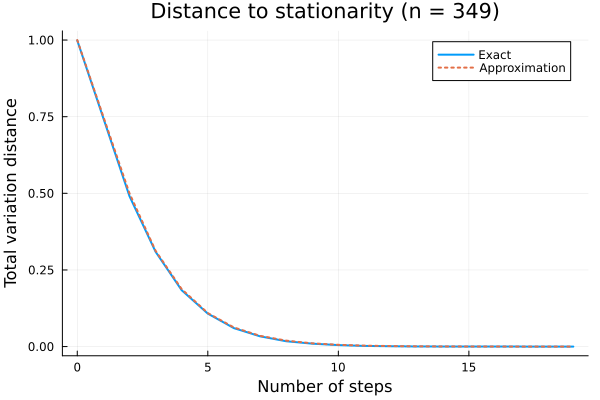

In [145]:
vals = 0:(2*n-1)
emperical_dist_ = sum(samples .== reshape(vals, 1, 1, :), dims = 1)./n_samples
emperical_dist = dropdims(emperical_dist_, dims=1)
stationary_dist = π(n, 2)
TV_dist = sum(abs.(emperical_dist .- reshape(stationary_dist,1,:)), dims = 2)/2
ts = 0:(reps-1)
approx = ones(reps)

nbin = NegativeBinomial(2, 1-1/2)
approx = 1 .- cdf(nbin, -1:(reps-2))

plt = plot(ts, TV_dist, label="Exact", linewidth = 2)
plot!(plt, ts, approx, label="Approximation",linewidth = 2, linestyle = :dot)
xlabel!(plt, "Number of steps")
ylabel!(plt, "Total variation distance")
title!(plt, "Distance to stationarity (n = 349)")
# savefig(plt, "../Figures/necklaces_13_pow_4.pdf")
plt

In [148]:
TV_dist

20×1 Matrix{Float64}:
 0.9988000000000107
 0.7376000000000008
 0.49339999999999856
 0.32219999999999643
 0.2087999999999992
 0.13479999999999917
 0.0905999999999995
 0.06290000000000007
 0.043100000000000076
 0.03260000000000002
 0.02410000000000002
 0.018399999999999996
 0.013099999999999999
 0.008900000000000009
 0.0068000000000000135
 0.005299999999999985
 0.004600000000000025
 0.0037000000000000184
 0.0028000000000000125
 0.002399999999999979

In [146]:
p = 360
m = 1
n = p^m
reps = 20
n_samples = 10000
samples = zeros(Int, n_samples, reps)
@showprogress for i in 1:n_samples
    _, js, rs = burnside_process(n, reps)
    samples[i, 1:reps] = n .* rs .+ js
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:03


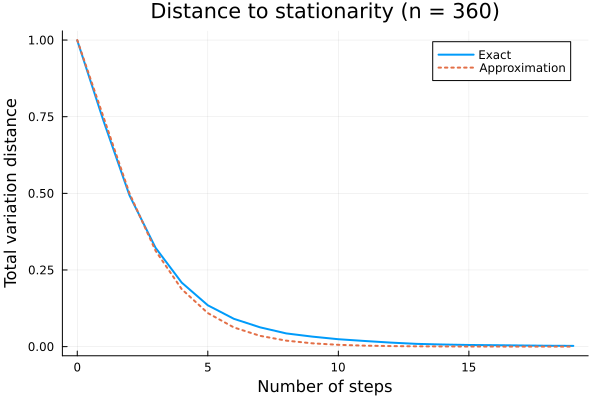

In [147]:
vals = 0:(2*n-1)
emperical_dist_ = sum(samples .== reshape(vals, 1, 1, :), dims = 1)./n_samples
emperical_dist = dropdims(emperical_dist_, dims=1)
stationary_dist = π(n, 2)
TV_dist = sum(abs.(emperical_dist .- reshape(stationary_dist,1,:)), dims = 2)/2
ts = 0:(reps-1)
approx = ones(reps)

nbin = NegativeBinomial(2, 1-1/2)
approx = 1 .- cdf(nbin, -1:(reps-2))

plt = plot(ts, TV_dist, label="Exact", linewidth = 2)
plot!(plt, ts, approx, label="Approximation",linewidth = 2, linestyle = :dot)
xlabel!(plt, "Number of steps")
ylabel!(plt, "Total variation distance")
title!(plt, "Distance to stationarity (n = 360)")
# savefig(plt, "../Figures/necklaces_13_pow_4.pdf")
plt